In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


In [16]:
dataset_link = "gagandeep16/car-sales" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\car-sales' already exists with files. Skipping download (replace=False).


In [17]:
files

['Car_sales.csv']

In [18]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [19]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(157, 16)

'Description'

,count,mean,std,min,25%,50%,75%,max
Sales_in_thousands,157.0,53.00,68.03,0.11,14.11,29.45,67.96,540.56
__year_resale_value,121.0,18.07,11.45,5.16,11.26,14.18,19.88,67.55
Price_in_thousands,155.0,27.39,14.35,9.24,18.02,22.80,31.95,85.50
Engine_size,156.0,3.06,1.04,1.00,2.30,3.00,3.58,8.00
Horsepower,156.0,185.95,56.70,55.00,149.50,177.50,215.00,450.00
Wheelbase,156.0,107.49,7.64,92.60,103.00,107.00,112.20,138.70
Width,156.0,71.15,3.45,62.60,68.40,70.55,73.43,79.90
Length,156.0,187.34,13.43,149.40,177.58,187.90,196.12,224.50
Curb_weight,155.0,3.38,0.63,1.90,2.97,3.34,3.80,5.57
Fuel_capacity,156.0,17.95,3.89,10.30,15.80,17.20,19.58,32.00


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
Manufacturer,object,0,30,"[Mercury, Volvo, Saturn]"
Model,object,0,156,"[Sonata, Altima, Carrera Coupe]"
Sales_in_thousands,float64,0,157,"[107.995, 8.588, 92.364]"
__year_resale_value,float64,36,117,"[7.75, 16.575, nan]"
Vehicle_type,object,0,2,"[Car, Passenger, Passenger]"
Price_in_thousands,float64,2,152,"[69.7, 25.345, 14.46]"
Engine_size,float64,1,31,"[3.0, 2.5, 4.0]"
Horsepower,float64,1,66,"[225.0, 240.0, 185.0]"
Wheelbase,float64,1,88,"[113.3, 114.2, 115.3]"
Width,float64,1,78,"[75.7, 71.0, 74.9]"


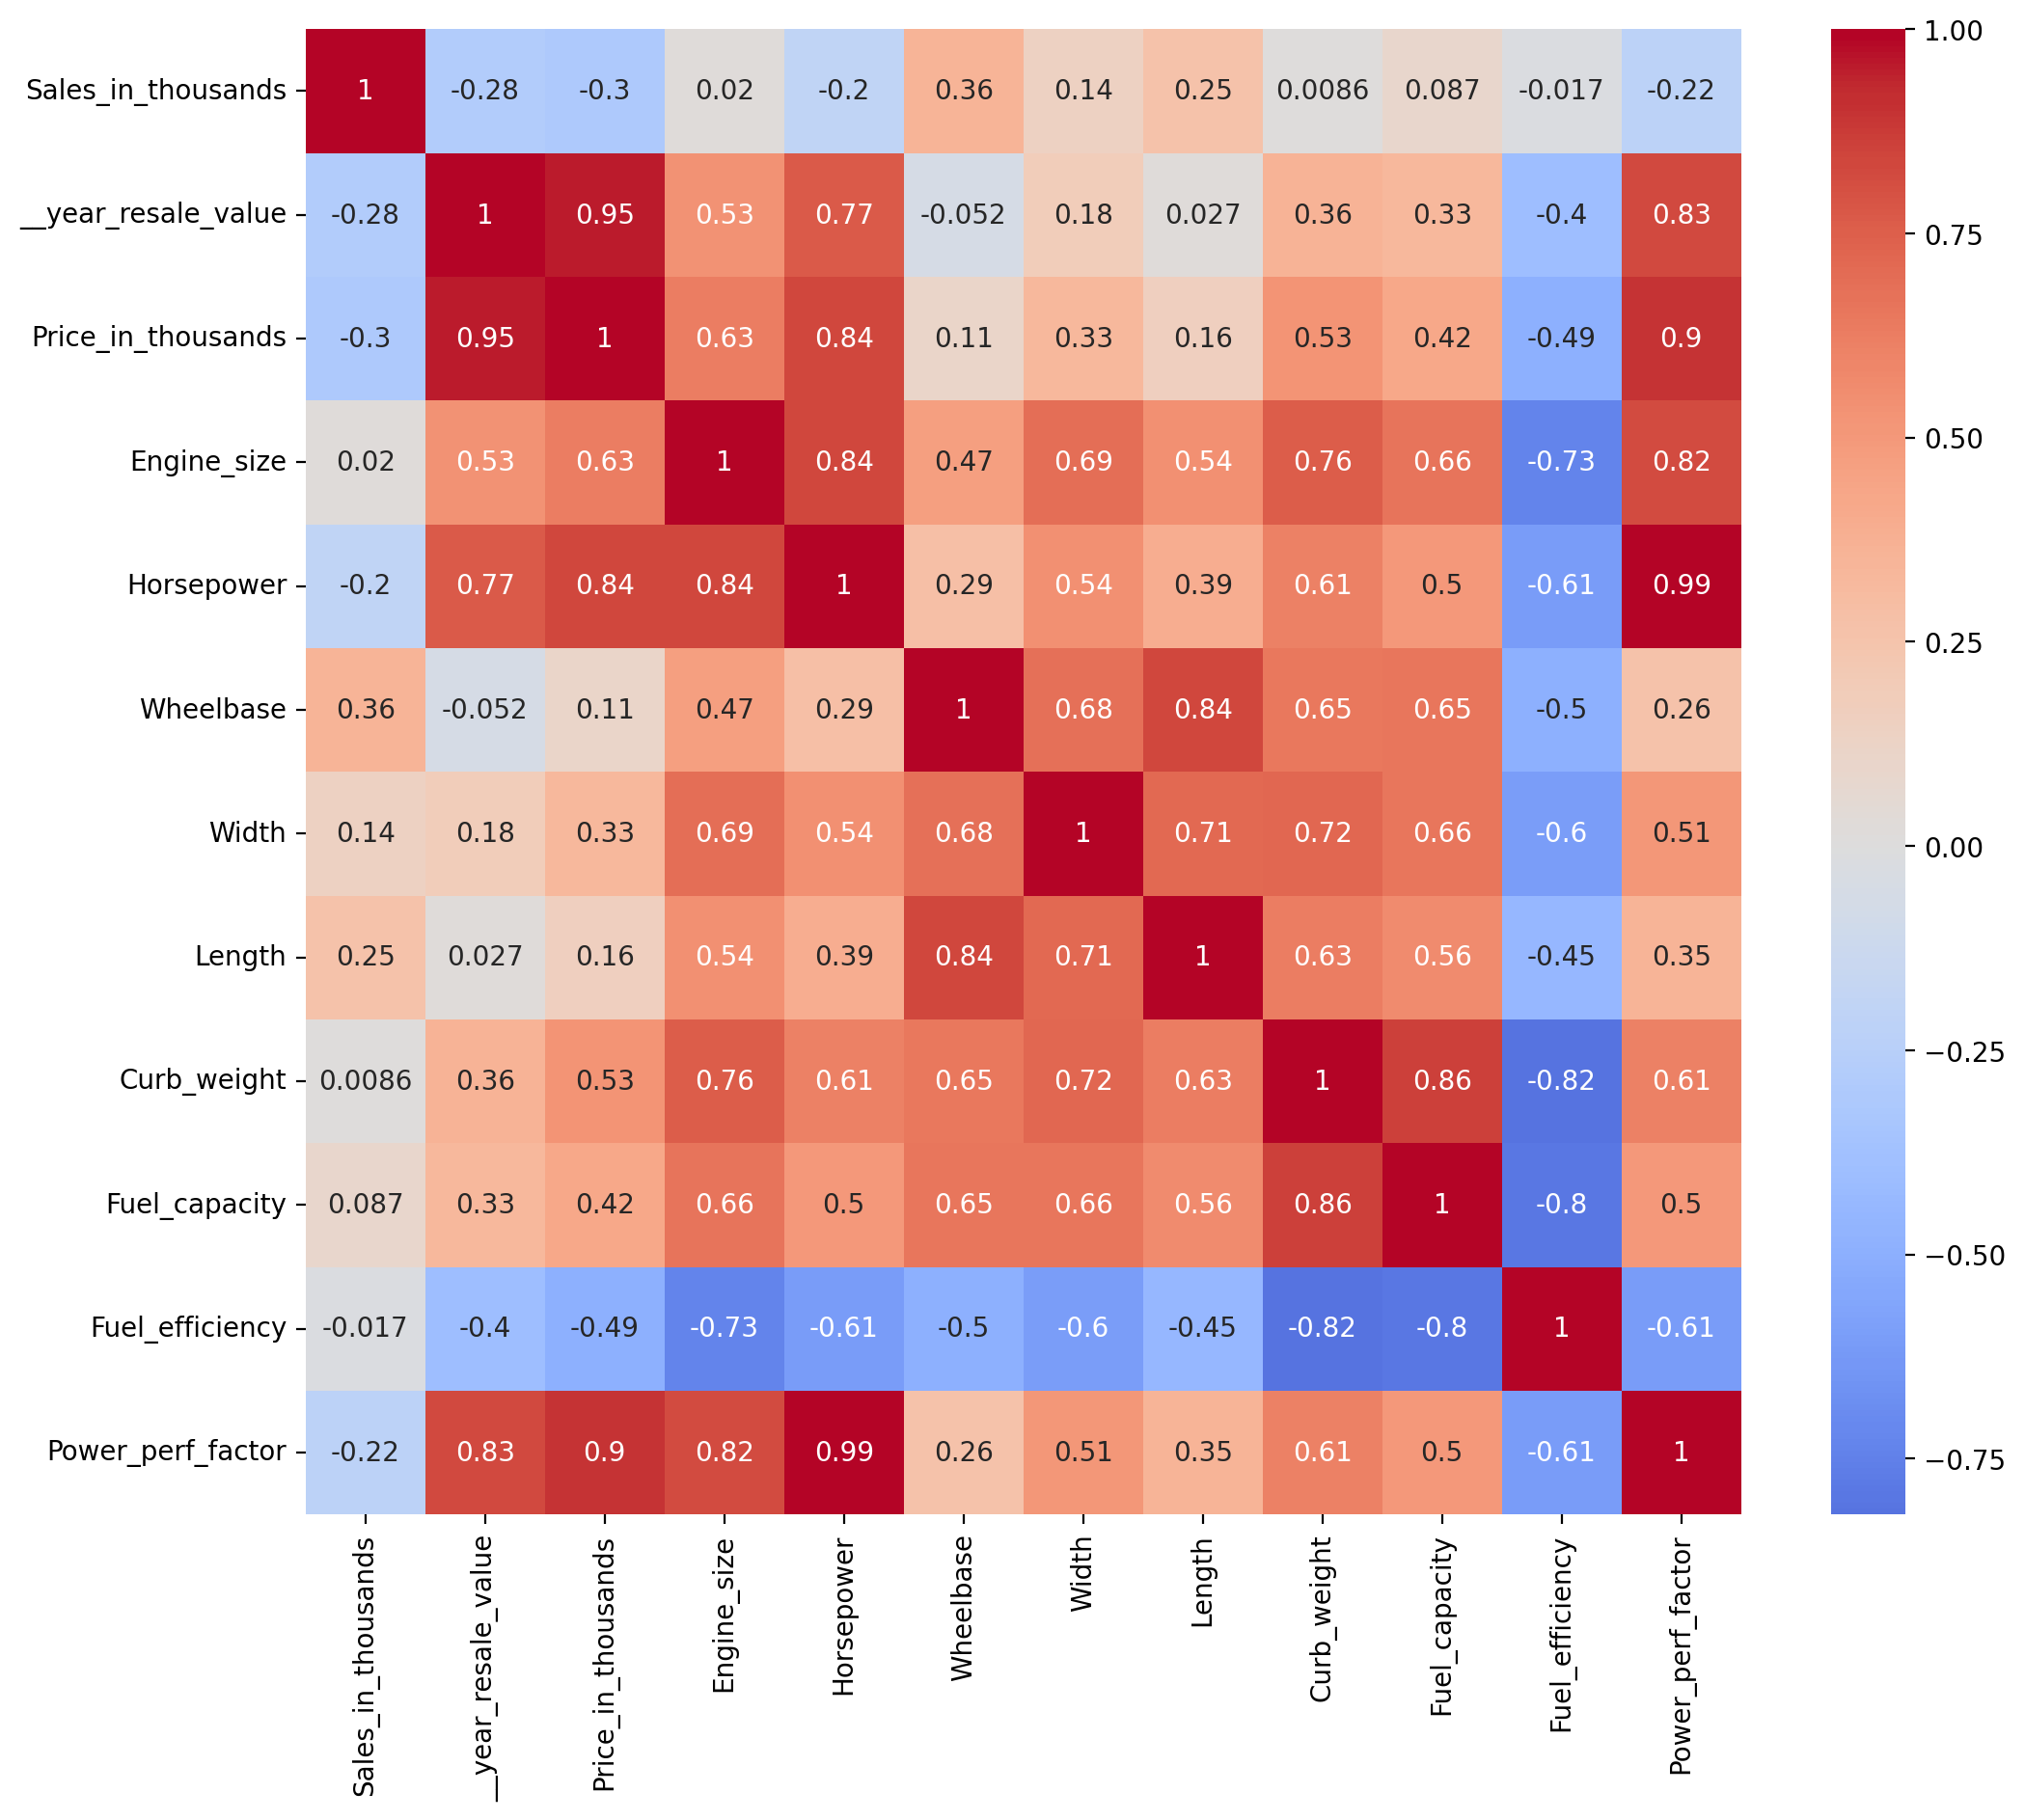

In [20]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=200)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);

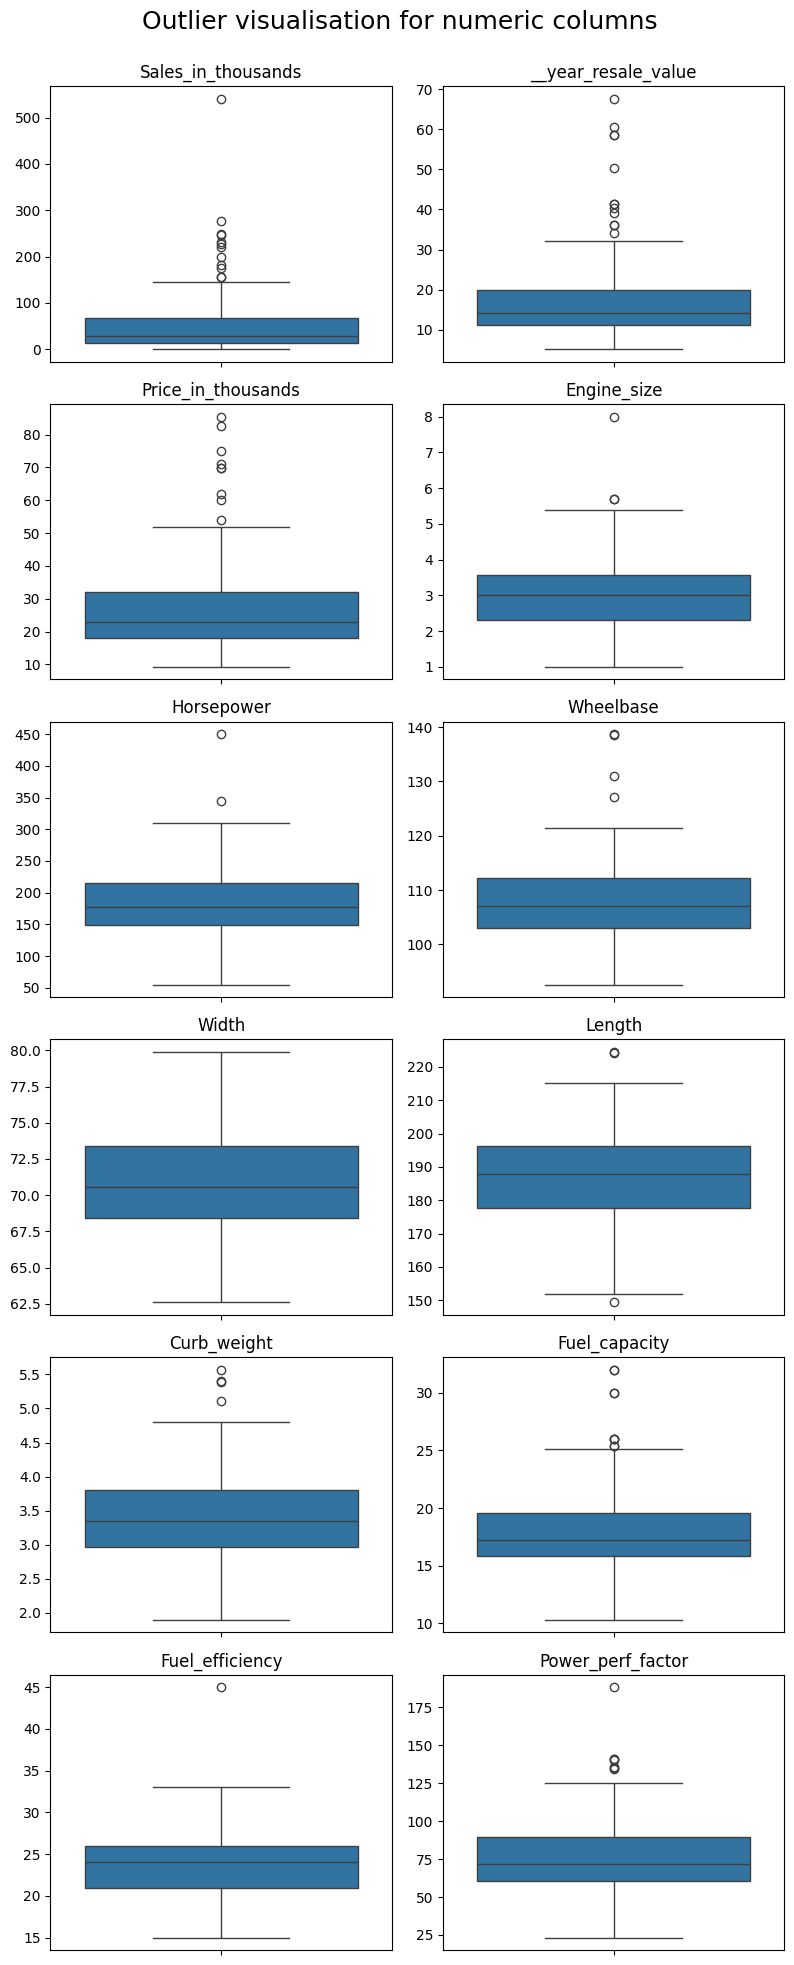

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=len(df.select_dtypes('number').columns)//2, ncols=2, figsize=[8,20])

col_counter = 0
row_counter = 0

for col in df.select_dtypes('number').columns:
    sns.boxplot(data=df[col], ax=ax[row_counter, col_counter])
    ax[row_counter, col_counter].set(title=col,
                    ylabel='')
    col_counter += 1
    if col_counter == 2:
        col_counter = 0
        row_counter += 1

fig.suptitle('Outlier visualisation for numeric columns', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.98]);

In [37]:
numeric_correlations = {col: df.corr(numeric_only=True).abs()[col].sort_values(ascending=False).index[1:4].tolist()
                              for col in df.corr(numeric_only=True).columns}

numeric_correlations

{'Sales_in_thousands': ['Wheelbase',
  'Price_in_thousands',
  '__year_resale_value'],
 '__year_resale_value': ['Price_in_thousands',
  'Power_perf_factor',
  'Horsepower'],
 'Price_in_thousands': ['__year_resale_value',
  'Power_perf_factor',
  'Horsepower'],
 'Engine_size': ['Horsepower', 'Power_perf_factor', 'Curb_weight'],
 'Horsepower': ['Power_perf_factor', 'Price_in_thousands', 'Engine_size'],
 'Wheelbase': ['Length', 'Width', 'Fuel_capacity'],
 'Width': ['Curb_weight', 'Length', 'Engine_size'],
 'Length': ['Wheelbase', 'Width', 'Curb_weight'],
 'Curb_weight': ['Fuel_capacity', 'Fuel_efficiency', 'Engine_size'],
 'Fuel_capacity': ['Curb_weight', 'Fuel_efficiency', 'Engine_size'],
 'Fuel_efficiency': ['Curb_weight', 'Fuel_capacity', 'Engine_size'],
 'Power_perf_factor': ['Horsepower',
  'Price_in_thousands',
  '__year_resale_value']}

In [ ]:
mask = df['Model'] == 'CL'

median_list = [df.groupby('Price_in_thousands')[col].median().loc[df.loc[mask,col].iloc[0]]
               for col in numeric_correlations['Price_in_thousands']
               if df.loc[mask, col].iloc[0] in df.groupby('Price_in_thousands')[col].groups]
print(median_list)

sum(median_list) / len(median_list)

[]


ZeroDivisionError: division by zero

In [ ]:
from sklearn.model_selection import train_test_split

features_train, features_test, target_train, target_test = train_test_split(df.iloc[:, [i for i in range(df.shape[1]) if i != 3]],
                                                                            df.iloc[:,2],
                                                                            test_size=0.1,
                                                                            random_state=42)

print(features_train)
print(target_train)

    Manufacturer          Model  Sales_in_thousands Vehicle_type  \
125      Porsche  Carrera Coupe               1.280    Passenger   
108   Oldsmobile        Cutlass               1.112    Passenger   
155        Volvo            C70               3.493    Passenger   
65      Infiniti            I30              23.713    Passenger   
119      Pontiac       Grand Am             131.097    Passenger   
..           ...            ...                 ...          ...   
71         Lexus          GS300              12.698    Passenger   
106       Nissan         Xterra              54.158          Car   
14      Cadillac        DeVille              63.729    Passenger   
92    Mercedes-B        C-Class              18.392    Passenger   
102       Nissan         Altima              88.094    Passenger   

     Price_in_thousands  Engine_size  Horsepower  Wheelbase  Width  Length  \
125              71.020          3.4       300.0       92.6   69.5   174.5   
108              18.145    

In [ ]:
mask = df.loc[:,'Price_in_thousands'].isna()

df.loc[mask,:].groupby('Model')['Price_in_thousands'].median()

Model
CL               NaN
Town & Country   NaN
Name: Price_in_thousands, dtype: float64

In [ ]:
mask = (df.loc[:,'Model'] == 'CL') | (df.loc[:,'Model'] == 'Town & Country')

df.loc[mask,:]

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.47,17.2,26.0,1/4/2012,NaN
33,Chrysler,Town & Country,53.480,19.540,Car,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7/13/2011,NaN


In [ ]:
print('Engine_size:')
print(df.groupby('Engine_size')['Price_in_thousands'].median().loc[3.2],'\n')

print('Horsepower:')
print(df.groupby('Horsepower')['Price_in_thousands'].median().loc[225.0],'\n')

print('__year_resale_value:')
print(df.groupby('__year_resale_value')['Price_in_thousands'].median().loc[18.225],'\n')

Engine_size:
35.3 

Horsepower:
33.1025 

__year_resale_value:
31.01 



In [ ]:
df.groupby('Model')['Price_in_thousands'].median().loc[['CL', 'Town & Country']]

Model
CL               NaN
Town & Country   NaN
Name: Price_in_thousands, dtype: float64

In [ ]:
def clean_data(data):
    '''
    Function to clean input data.

    Changing datatypes to the desired ones and filling missing values with appropiate ones.

    Args:
        data (dataframe): pandas Dataframe with the features to be cleaned.

    Return:
        clean_data (dataframe): The cleaned input data
    
    '''

    features = data.copy()

    